# This notebook was used to compare the results of Transformer-40k and SpliceAI-10k resulting from the test scripts run in Compute Canada

In [1]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle

from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score
import copy

from src.train import trainModel
#from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn
from src.dataloader import getData,spliceDataset,h5pyDataset,getDataPointList,getDataPointListFull,DataPointFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model import SpliceFormer
from src.evaluation_metrics import print_topl_statistics,cross_entropy_2d
from src.gpu_metrics import run_bootstrap, calculate_ap, calculate_topk
import os

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_top_k(y_true, y_pred):
    idx_true = np.nonzero(y_true == 1)[0]
    argsorted_y_pred = np.argsort(y_pred)
    sorted_y_pred = np.sort(y_pred)

    topkl_accuracy = []
    threshold = []
    top_length = 1
    idx_pred = argsorted_y_pred[-int(top_length*len(idx_true)):]
    correct = np.size(np.intersect1d(idx_true, idx_pred))
    total = float(min(len(idx_pred), len(idx_true)))
    if top_length == 1:
        correct_1 = correct
        total_1 = total
    topkl_accuracy += [ correct/ total]
    threshold += [sorted_y_pred[-int(top_length*len(idx_true))]]
    return topkl_accuracy,threshold

### Transformer-40 performance on ENSEMBL test set

In [3]:
transformer = pd.read_csv('../Data/transformer_40k_test_ensembl_predictions_300625.csv.gz')
transformer

,Y_true_acceptor,Y_pred_acceptor,Y_true_donor,Y_pred_donor
0,0.0,2.336246e-07,0.0,0.000002
1,0.0,2.312783e-07,0.0,0.000003
2,0.0,4.485540e-08,0.0,0.000007
3,0.0,2.567490e-07,0.0,0.000005
4,0.0,1.211019e-07,0.0,0.000001
...,...,...,...,...
664939995,0.0,3.311274e-06,0.0,0.000008
664939996,0.0,3.702454e-06,0.0,0.000008
664939997,0.0,3.740225e-06,0.0,0.000008
664939998,0.0,3.670163e-06,0.0,0.000007


In [4]:
print('TRANSFORMER-40K: TOP-K AND AVERAGE PRECISION')
device = torch.device("cpu")
Y_true_acceptor = torch.as_tensor(transformer['Y_true_acceptor'].values, dtype=torch.int8).to(device)
Y_pred_acceptor = torch.as_tensor(transformer['Y_pred_acceptor'].values, dtype=torch.float32).to(device)
Y_true_donor = torch.as_tensor(transformer['Y_true_donor'].values, dtype=torch.int8).to(device)
Y_pred_donor = torch.as_tensor(transformer['Y_pred_donor'].values, dtype=torch.float32).to(device)


# Compute scores
ap_score = calculate_ap(Y_true_acceptor, Y_pred_acceptor, Y_true_donor, Y_pred_donor, device, device)
topk_score = calculate_topk(Y_true_acceptor, Y_pred_acceptor, Y_true_donor, Y_pred_donor)

print(f"Average Precision: {ap_score:.4f}")
print(f"Top-k Accuracy: {topk_score:.4f}")

TRANSFORMER-40K: TOP-K AND AVERAGE PRECISION
Average Precision: 0.9687
Top-k Accuracy: 0.9433


In [5]:
print('TRANSFORMER-40K: PERFORMANCE AT THRESHOLD')
threshold = 0.8

detected_acceptors = np.sum((transformer.Y_true_acceptor == 1) & (transformer.Y_pred_acceptor >= threshold))
missed_acceptors   = np.sum((transformer.Y_true_acceptor == 1) & (transformer.Y_pred_acceptor < threshold))
total_acceptors    = np.sum(transformer.Y_true_acceptor == 1)

print(f"Detected acceptor sites: {detected_acceptors} / {total_acceptors}")
print(f"Missed acceptor sites:   {missed_acceptors}")
print('Ratio:', detected_acceptors / total_acceptors)

detected_donor = np.sum((transformer.Y_true_donor == 1) & (transformer.Y_pred_donor >= threshold))
missed_donor  = np.sum((transformer.Y_true_donor == 1) & (transformer.Y_pred_donor < threshold))
total_donor    = np.sum(transformer.Y_true_donor == 1)

print(f"Detected donor sites: {detected_donor} / {total_donor}")
print(f"Missed donor sites:   {missed_donor}")
print('Ratio:', detected_donor / total_donor)

print('Total Ratio:', ((detected_acceptors / total_acceptors) + (detected_donor / total_donor))/2)

TRANSFORMER-40K: PERFORMANCE AT THRESHOLD
Detected acceptor sites: 78493 / 89712
Missed acceptor sites:   11219
Ratio: 0.8749442660959514
Detected donor sites: 79746 / 89712
Missed donor sites:   9966
Ratio: 0.8889111824505083
Total Ratio: 0.8819277242732299


Top-k accuracy has a certain threshold asociated with it, which isn't returned from the 'calculate_topk' function in the src.gpu_metrics file. So I just used the earlier defined function get_top_k to calculate the top-k value in the same way but with returning the threshold for donor and acceptor.

In [6]:
print('TRANSFORMER-40K: TOP-K ACCURARCY')
transformer_acc_topk,transformer_acc_threshold = get_top_k(transformer.Y_true_acceptor.values, transformer.Y_pred_acceptor.values)
transformer_donor_topk,transformer_donor_threshold = get_top_k(transformer.Y_true_donor.values, transformer.Y_pred_donor.values)
print('Acceptor:',transformer_acc_topk,transformer_acc_threshold)
print('Donor:',transformer_donor_topk,transformer_donor_threshold)
print('Total:',(transformer_acc_topk[0]+transformer_donor_topk[0])/2)

TRANSFORMER-40K: TOP-K ACCURARCY
Acceptor: [0.9408663278045301] [np.float64(0.45556268)]
Donor: [0.9457040306759408] [np.float64(0.4889393)]
Total: 0.9432851792402355


In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score
transformer_acc_precision,transformer_acc_recall,transformer_acc_thresholds = precision_recall_curve(Y_true_acceptor,Y_pred_acceptor) 
transformer_acc_ap = average_precision_score(Y_true_acceptor,Y_pred_acceptor) 
print(f"Average Precision (PR-AUC): {transformer_acc_ap}")


Average Precision (PR-AUC): 0.967041735623258


In [8]:
transformer_don_precision,transformer_don_recall,transformer_don_thresholds = precision_recall_curve(Y_true_donor,Y_pred_donor) 
transformer_don_ap = average_precision_score(Y_true_donor,Y_pred_donor) 
print(f"Average Precision (PR-AUC): {transformer_don_ap}")

Average Precision (PR-AUC): 0.9704367403936418


/var/folders/b4/wk8m28x57xn6sy326ngv7k5m0000gn/T/ipykernel_14664/915448896.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../Results/precision-recall-curve.png',dpi=400)
/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


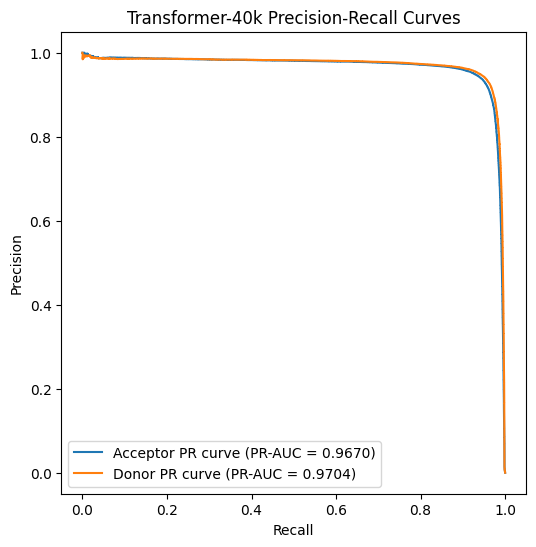

In [10]:
plt.figure(figsize=(6, 6))
plt.plot(transformer_acc_recall, transformer_acc_precision, label=f'Acceptor PR curve (PR-AUC = {transformer_acc_ap:.4f})')
plt.plot(transformer_don_recall, transformer_don_precision, label=f'Donor PR curve (PR-AUC = {transformer_don_ap:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Transformer-40k Precision-Recall Curves')
plt.legend()
plt.savefig('../Results/precision-recall-curve.png',dpi=400)
plt.show()

### SpliceAI-10k model performance on ENSEMBL test set

SpliceAI appeared to perform better than Transformer-40k. After communicating the the authors of the paper it turns out the specific saved spliceai model weights (spliceai_encoder_10k_071122_i) were accidentally trained on both train AND test set. This is why it seemed to perform better. The author later provided the proper spliceai weights that were used in the paper (spliceai_encoder_10k_191022_i). However, at the time of reproducing the paper results I had the earlier version (spliceai_encoder_10k_071122_i), so the saved results (spliceai_10k_test_ensembl_predictions_300625.csv.gz) reflect this

In [2]:
spliceai = pd.read_csv('../Data/spliceai_10k_test_ensembl_predictions_300625.csv.gz')
spliceai

,Y_true_acceptor,Y_pred_acceptor,Y_true_donor,Y_pred_donor
0,0.0,5.405732e-07,0.0,9.749649e-06
1,0.0,4.137088e-07,0.0,2.795269e-06
2,0.0,3.342412e-07,0.0,2.451711e-05
3,0.0,6.124780e-07,0.0,7.294009e-06
4,0.0,8.705280e-07,0.0,2.021087e-06
...,...,...,...,...
664939995,0.0,1.134575e-06,0.0,1.238303e-06
664939996,0.0,1.777195e-06,0.0,9.238735e-07
664939997,0.0,1.403097e-06,0.0,9.033723e-07
664939998,0.0,1.227144e-06,0.0,5.584995e-07


In [8]:
print('SPLICEAI-10K: PERFORMANCE AT THRESHOLD')
threshold = 0.8

detected_acceptors = np.sum((spliceai.Y_true_acceptor == 1) & (spliceai.Y_pred_acceptor >= threshold))
missed_acceptors   = np.sum((spliceai.Y_true_acceptor == 1) & (spliceai.Y_pred_acceptor < threshold))
total_acceptors    = np.sum(spliceai.Y_true_acceptor == 1)

print(f"Detected acceptor sites: {detected_acceptors} / {total_acceptors}")
print(f"Missed acceptor sites:   {missed_acceptors}")
print('Ratio:', detected_acceptors / total_acceptors)

detected_donor = np.sum((spliceai.Y_true_donor == 1) & (spliceai.Y_pred_donor >= threshold))
missed_donor  = np.sum((spliceai.Y_true_donor == 1) & (spliceai.Y_pred_donor < threshold))
total_donor    = np.sum(spliceai.Y_true_donor == 1)

print(f"Detected donor sites: {detected_donor} / {total_donor}")
print(f"Missed donor sites:   {missed_donor}")
print('Ratio:', detected_donor / total_donor)

print('Total Ratio:', ((detected_acceptors / total_acceptors) + (detected_donor / total_donor))/2)

SPLICEAI-10K: PERFORMANCE AT THRESHOLD
Detected acceptor sites: 84890 / 89712
Missed acceptor sites:   4822
Ratio: 0.9462502229356162
Detected donor sites: 85498 / 89712
Missed donor sites:   4214
Ratio: 0.9530274656679151
Total Ratio: 0.9496388443017656


In [3]:
print('SPLICEAI-10K: TOP-K AND AVERAGE PRECISION')
device = torch.device("cpu")
Y_true_acceptor = torch.as_tensor(spliceai['Y_true_acceptor'].values, dtype=torch.int8).to(device)
Y_pred_acceptor = torch.as_tensor(spliceai['Y_pred_acceptor'].values, dtype=torch.float32).to(device)
Y_true_donor = torch.as_tensor(spliceai['Y_true_donor'].values, dtype=torch.int8).to(device)
Y_pred_donor = torch.as_tensor(spliceai['Y_pred_donor'].values, dtype=torch.float32).to(device)


# Compute scores
ap_score = calculate_ap(Y_true_acceptor, Y_pred_acceptor, Y_true_donor, Y_pred_donor, device, device)
topk_score = calculate_topk(Y_true_acceptor, Y_pred_acceptor, Y_true_donor, Y_pred_donor)

print(f"Average Precision: {ap_score:.4f}")
print(f"Top-k Accuracy: {topk_score:.4f}")

SPLICEAI-10K: TOP-K AND AVERAGE PRECISION
Average Precision: 0.9933
Top-k Accuracy: 0.9706
